In [35]:
import allel
print("allel:",allel.__version__)
import numpy as np
import scipy as sp
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

import tabix
import random

from math import isnan, isfinite

allel: 1.3.5
numpy: 1.21.6


In [2]:
from plotnine import *

In [3]:
vcffile='resources/Aaeg1200g/aegy.wgs.aaa.aaf.norep5-30x.ac10.thinrand01.phased.chr1.vcf.gz'
metafile='resources/meta_Aaeg1kg_spp.txt'
invfile='resources/lostruct_inversions_table.txt'


In [33]:
#meta = pd.read_csv(metafile, sep='\t')
meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')

invs = pd.read_csv(invfile, sep='\t')



array(['Debug019_aegypti_El_Dorado_Argentina_U_10',
       'Debug019_aegypti_El_Dorado_Argentina_U_11',
       'Debug019_aegypti_El_Dorado_Argentina_U_2', ...,
       'Debug010_aegypti_Tahiti_FrenchPolynesia_18',
       'Debug010_aegypti_Tahiti_FrenchPolynesia_19',
       'Debug010_aegypti_Tahiti_FrenchPolynesia_20'], dtype='<U59')

In [39]:
bgrldsamps = random.sample(sorted(meta['sample']),100)


callset1 = allel.read_vcf(vcffile, samples=bgrldsamps, fields='*')
altcounts = callset1['calldata/GT'][:,:,0] + callset1['calldata/GT'][:,:,1]

#remove all non-variant sites
hasvar = np.logical_not(np.any(np.vstack([np.all(altcounts==2,1),
           np.all(altcounts==1,1),
           np.all(altcounts==0,1)]),0))

goodposn = callset1['variants/POS'][hasvar]
goodcounts = altcounts[hasvar,:]

bsize=500000

r2bgr, r2wins, r2nbgr  = allel.windowed_r_squared(goodposn, goodcounts, 
                                            size=bsize, start=0, stop=310000000, step=bsize, percentile=50)

dict_keys(['samples', 'calldata/GT', 'variants/AC', 'variants/AF', 'variants/ALT', 'variants/CHROM', 'variants/CM', 'variants/FILTER_PASS', 'variants/ID', 'variants/POS', 'variants/QUAL', 'variants/REF', 'variants/altlen', 'variants/is_snp', 'variants/numalt'])

In [42]:
pop1 = 'Senegal'
column='country'
pop1samps = meta['sample'][meta[column]==pop1]

In [43]:
callset1 = allel.read_vcf(vcffile, samples=pop1samps, fields='*')
#gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
#acpop1 = gtpop1.count_alleles()
altcounts = callset1['calldata/GT'][:,:,0] + callset1['calldata/GT'][:,:,1]

#remove all non-variant sites
hasvar = np.logical_not(np.any(np.vstack([np.all(altcounts==2,1),
           np.all(altcounts==1,1),
           np.all(altcounts==0,1)]),0))

goodposn = callset1['variants/POS'][hasvar]
goodcounts = altcounts[hasvar,:]

bsize=500000

r2, r2wins, r2n  = allel.windowed_r_squared(goodposn, goodcounts, 
                                            size=bsize, start=0, stop=310000000, step=bsize, percentile=50)

In [60]:
r2normfact = r2bgr/np.mean(r2bgr)


In [64]:
r2norm = r2*r2normfact

In [67]:
goodcolinear = np.array([True]*len(r2wins))

invflank=1e6

for ii in range(0,len(invs['inv_name'])):
    inm = invs['inv_name'][ii]
    ist = invs['start'][ii]
    ien = invs['end'][ii]
    goodcolinear[np.logical_and(r2wins[:,0] > (ist-invflank), r2wins[:,1] < (ien+invflank))] = False

goodcolinear
noninvr2 = r2norm[goodcolinear]
meanr2noninv = np.mean(noninvr2)
round(meanr2noninv,5)


0.004

In [66]:
ii=0
plim = 0.01
for ii in range(0,len(invs['inv_name'])):
    inm = invs['inv_name'][ii]
    ist = invs['start'][ii]
    ien = invs['end'][ii]

    invr2 = r2norm[np.logical_and(r2wins[:,0]>=ist, r2wins[:,1]<=ien)]
    
    test = sp.stats.ttest_ind(invr2, noninvr2)
    meanr2inv = np.mean(invr2)
    print(inm,ist,ien,round(meanr2inv,4),round(meanr2inv-meanr2noninv,4),test.pvalue)

1a 1500000 17000000 0.0033 -0.0007 0.028681772756066513
1b 107000000 109500000 0.0059 0.0019 0.008677694499051146
1c 148000000 160500000 0.0113 0.0073 1.3853078876283842e-19
1d 162000000 170500000 0.0111 0.0071 8.178824996992098e-44
1e 248500000 252000000 0.0033 -0.0007 0.2477807732931686
1f 264500000 309000000 0.0029 -0.0011 2.323373832554435e-10
1g 302500000 308000000 0.0027 -0.0013 0.01022019845331322
2a 227000000 239000000 0.0037 -0.0003 0.3068399197401151
2b 306500000 317000000 0.002 -0.002 0.001193923230411122
2c 464500000 473000000 nan nan nan


In [32]:
"    ".join(map(str,[country,inm,ist,ien,round(meanr2inv,4),round(meanr2inv-meanr2noninv,4),test.pvalue]))

'1c    464500000    473000000    nan    nan    nan'

In [82]:
r2tab = pd.DataFrame({"start":r2wins[:,0],
 "end":r2wins[:,1],
 "r2bgr":r2bgr,
 "r2samp":r2,
 "r2bgrnorm":r2bgr/r2normfact,
 "r2sampnorm":r2norm                     
                     
                     })

r2tab['pos'] = r2tab["start"]+round(bsize/2)

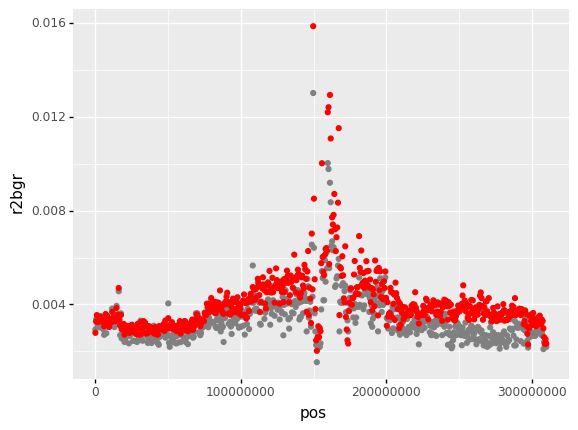

In [83]:
p = ggplot(r2tab,aes(x='pos',y='r2bgr')) + \
  geom_point(colour="grey") + \
  geom_point(aes(y='r2samp'),colour="red") + \
  theme(legend_position="bottom") 
print(p)


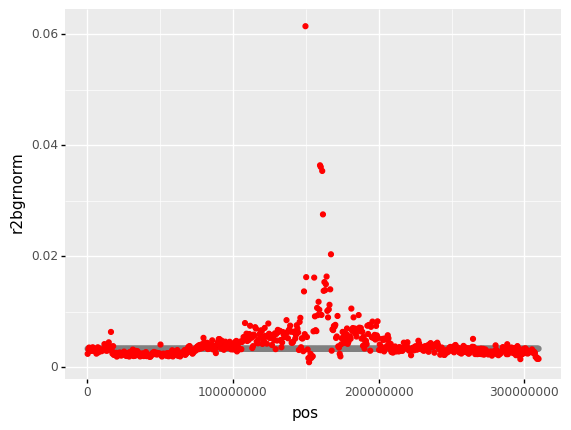

In [84]:
p = ggplot(r2tab,aes(x='pos',y='r2bgrnorm')) + \
  geom_point(colour="grey") + \
  geom_point(aes(y='r2sampnorm'),colour="red") + \
  theme(legend_position="bottom") 
print(p)
